# Notebook Description

### Import libraries

In [3]:
%matplotlib inline
import os
import sys
import time
import pathlib
import matplotlib.pyplot as plt

### Import Autoencoder class

In [190]:
folder_path = str(pathlib.Path().resolve().parents[1])
print("Folder path =", folder_path)

base_data_path = 'D:\RORcogmaps_data'
plot_folder_path = folder_path + '/Plots/Experiment2/'
model_folder_path = folder_path + '/Models/Experiment2/'

sys.path.append(folder_path + '/Notebooks/Spatial_AE')

from data import *
from model import *
from training import *
from plotting import *
from analysis import *
from dataloaders import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps


### Check GPU

In [7]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


## Autoencoder Hyperparameters

In [9]:
#Experiment
model_training = False
model_saving = True
save_plots = True
save_supp_plots = False

#Model
n_hidden = 400
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

In [10]:
env = "DoubleTmazeNoReward"
model_filename =  env + '-Epochs' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
model_path = model_folder_path + model_filename
loss_csv_filename = model_folder_path + '/' + model_filename[:-4] + '_loss_history.csv'

# Import No Reward DoubleTMaze image dataset and CSV data

In [12]:
data_path, csv_filename, num_images = format_dataset(base_data_path, env)

print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Num. Images in Dataset = 40001
Dataset Path = D:\RORcogmaps_data/Datasets/DoubleTmazeNoReward
CSV path =     D:\RORcogmaps_data/Datasets/DoubleTmazeNoReward/data.csv


In [13]:
noReward_DTmaze_data, noReward_DTmaze_position, noReward_DTmaze_orientation = load_csv(csv_filename, num_images)

In [14]:
noReward_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

In [15]:
frames_to_remove = check_missing_frame(noReward_DTmaze_data)
noReward_dataset = clean_dataset(noReward_dataset, frames_to_remove)

print("Dataset Shape =", noReward_dataset.shape)
print("Position Shape =", noReward_DTmaze_position.shape)
print()
noReward_DTmaze_data

Frames ID to be removed from dataset = [19681]
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.499, 0.999, 0.999, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[4.71, 6.28]",False,0.020396,0.090619,298.177441,"[0.498, 0.998, 0.998, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[0.0, 1.57]",False,0.029349,0.108280,330.537874,"[0.497, 0.997, 0.997, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[4.71, 3.14]",False,0.086920,0.156429,300.829370,"[0.496, 0.996, 0.996, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[-0.79, 0.79]",False,0.084543,0.162494,332.615980,"[0.495, 0.995, 0.995, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,32,761.856,39996,[],"[4.71, 6.28]",False,-0.801587,-1.003430,285.588582,"[0.0001, 0.256, 0.256, 0.256]",0,"[0, 0, 0, 0]",0
39995,32,762.880,39997,[],"[4.71, 3.93]",False,-0.785099,-0.913312,270.114361,"[0.0001, 0.255, 0.255, 0.255]",0,"[0, 0, 0, 0]",0
39996,32,763.904,39998,[],"[4.71, 3.14]",False,-0.799692,-0.840132,239.542245,"[0.0001, 0.254, 0.254, 0.254]",0,"[0, 0, 0, 0]",0
39997,32,764.928,39999,[],"[3.14, 1.57]",False,-0.831059,-0.816271,207.274266,"[0.0001, 0.253, 0.253, 0.253]",0,"[0, 0, 0, 0]",0


### Display example image

Image shape = (120, 160, 3)


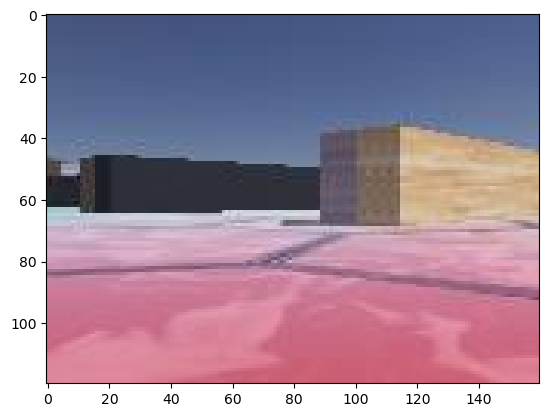

In [17]:
idx = 46
plt.imshow(noReward_dataset[idx])
print("Image shape =", noReward_dataset[idx].shape)

## Dataset exploration (No Reward)

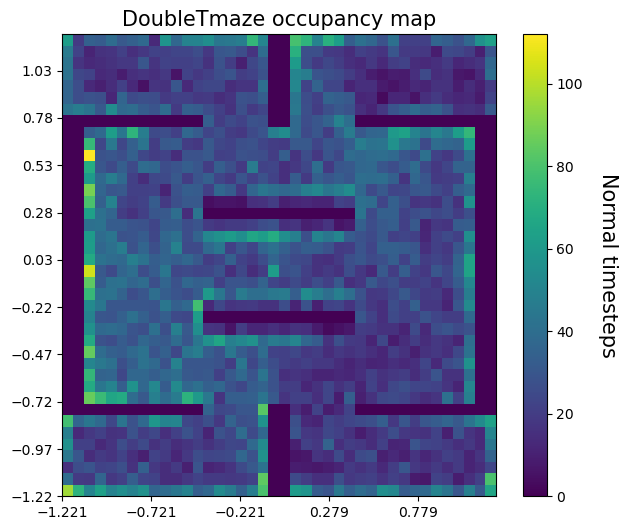

In [19]:
noReward_hist = plot_occupancy_map(noReward_DTmaze_position, plot_folder_path, save=False)

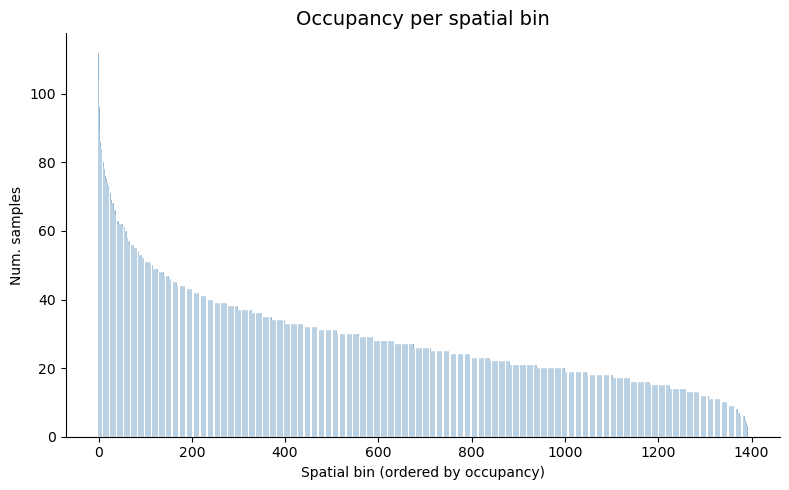

In [20]:
plot_samples_per_bin_hist(noReward_hist)

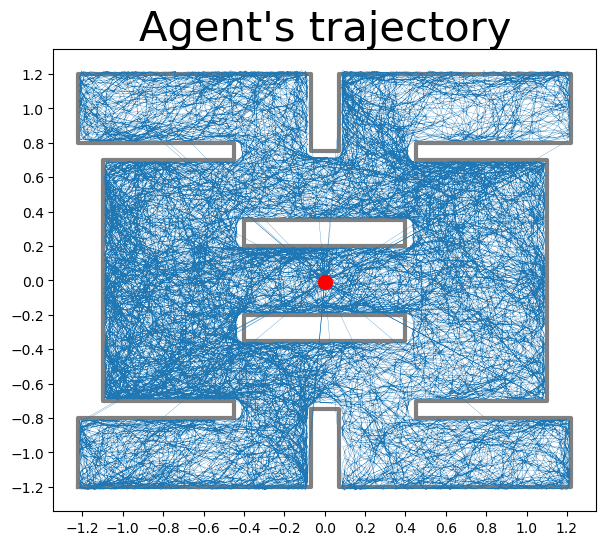

In [21]:
plot_agent_trajectory(noReward_DTmaze_position, plot_folder_path, save=False)

# Train or Load Autoencoder

In [23]:
if model_training == True:
    start_time = time.time()
    model = Conv_AE(n_hidden=n_hidden)
    train_loader = create_dataloader(noReward_dataset, batch_size=batch_size)
    history, _= train_autoencoder(model, train_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

    elapsed_time = time.time() - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    timer = "Training duration: " + "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(seconds))
    print(timer, end="\r")

    #Saving loss history in a CSV file
    save_training_loss(loss_csv_filename, history)

    if model_saving == True:
        print("Autoencoder saved at", model_path)
        torch.save(model.state_dict(), model_path)

### Load

In [25]:
if model_training == False:
    try:
        model = Conv_AE(n_hidden=n_hidden)
        model.load_state_dict(torch.load(model_path))
        print("Model loaded:", model_path)
        history = pd.read_csv(loss_csv_filename)['Image_loss'].tolist()
    except:
      print("An exception occurred - No available Autoencoder")

Model loaded: C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Models/Experiment2/DoubleTmazeNoReward-Epochs100-NHidden400-BSize256-C1000.0-A100000.0-LR0.0001.pth


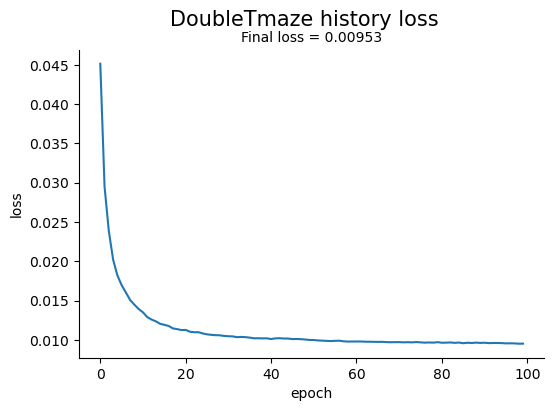

In [26]:
fig = plt.figure(figsize=(6,4))
plt.plot(history)
plt.xlabel('epoch')
plt.ylabel('loss')
sb.despine()
plt.suptitle('DoubleTmaze history loss', fontsize=15)
plt.title('Final loss = ' + str(round(history[-1], 5)), fontsize=10)
plt.show()

X position = 0.127
Y position = 0.177


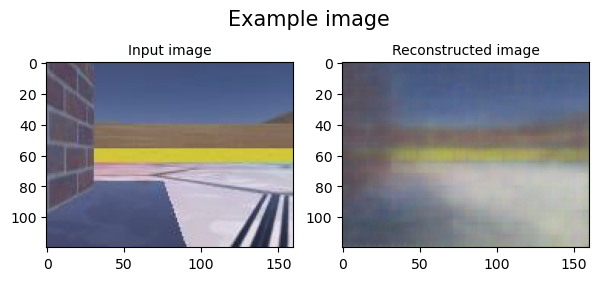

In [27]:
img_indx = 5
print('X position =', round(noReward_DTmaze_position[img_indx][0],3))
print('Y position =', round(noReward_DTmaze_position[img_indx][1],3))

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(noReward_dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(noReward_dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

## Evaluating embedding activity (No Reward)

In [29]:
noReward_embeddings = get_latent_vectors(noReward_dataset, model, batch_size=batch_size)

In [30]:
noReward_max_activity = []
noReward_mean_activity = []
activity_threshold = 0.001
noReward_num_active_units = []

for i in range(len(noReward_embeddings)):
    noReward_max_activity.append(np.max(noReward_embeddings[i]))
    noReward_mean_activity.append(np.mean(noReward_embeddings[i]))
    noReward_num_active_units.append(np.sum(noReward_embeddings[i] > activity_threshold))

Mean Embedding Max. Activity = 16.943844
Std. Embedding Max. Activity = 3.7607465


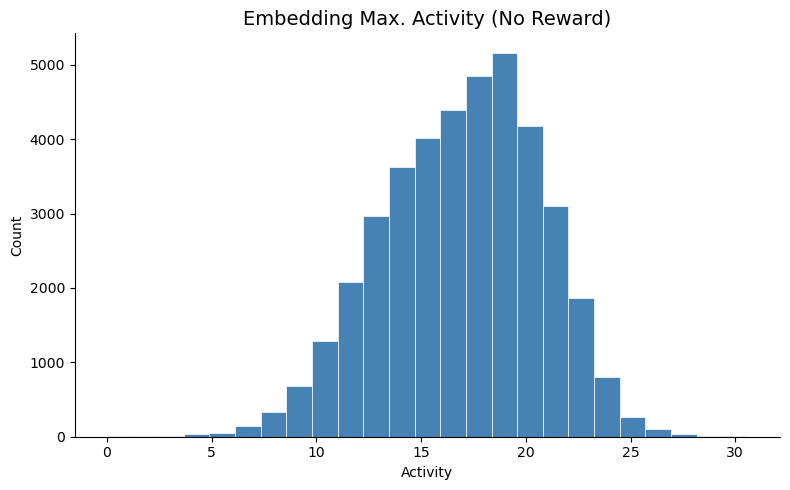

In [31]:
print('Mean Embedding Max. Activity =', np.mean(noReward_max_activity))
print('Std. Embedding Max. Activity =', np.std(noReward_max_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward_max_activity, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Max. Activity (No Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Mean Activity = 0.061163772
Std. Embedding Mean Activity = 0.012515285


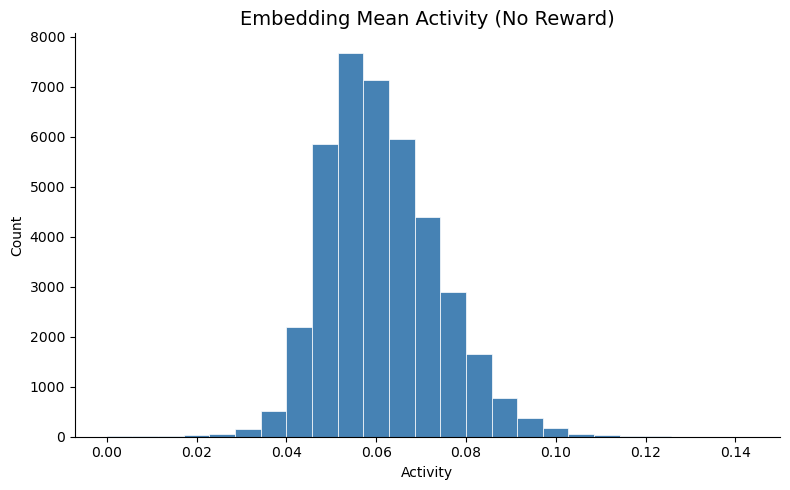

In [32]:
print('Mean Embedding Mean Activity =', np.mean(noReward_mean_activity))
print('Std. Embedding Mean Activity =', np.std(noReward_mean_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward_mean_activity, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Mean Activity (No Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Active Units = 2.670166754168854
Std. Embedding Active Units = 1.1993638778688187


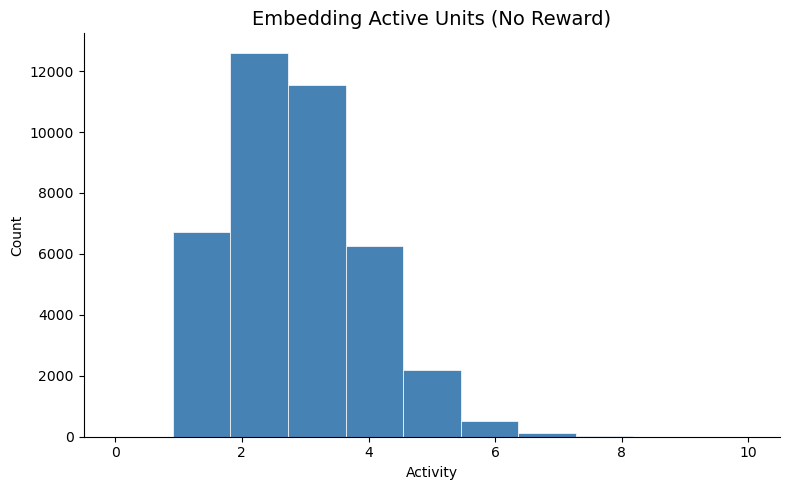

In [33]:
print('Mean Embedding Active Units =', np.mean(noReward_num_active_units))
print('Std. Embedding Active Units =', np.std(noReward_num_active_units))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward_num_active_units, bins=11, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Active Units (No Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Embedding dynamics in DoubleTmaze

In [35]:
noReward_sample_loss = []
for i in range(len(noReward_dataset)):
    noReward_sample_loss.append(img_reconstruction_loss(model, noReward_dataset[i]))

In [36]:
noReward_sample_error_map = []
for i in range(len(noReward_dataset)):
    error_map = img_pixelwise_reconstruction_loss(model, noReward_dataset[i])
    noReward_sample_error_map.append(np.percentile(error_map, 98))

In [37]:
baseline_max_activity    = np.mean(noReward_max_activity)
baseline_mean_activity   = np.mean(noReward_mean_activity)
baseline_num_active_units = np.mean(noReward_num_active_units)
baseline_sample_loss     = np.mean(noReward_sample_loss)
baseline_error_map       = np.mean(noReward_sample_error_map)

In [38]:
noReward_relative_max_activity = []
noReward_relative_mean_activity = []
noReward_relative_num_active_units = []
noReward_relative_sample_loss = []
noReward_relative_error_map = []

for i in range(len(noReward_embeddings)):
    #noReward_relative_max_activity.append(np.max(noReward_embeddings[i]) - np.mean(noReward_max_activity))
    #noReward_relative_mean_activity.append(np.mean(noReward_embeddings[i]) - np.mean(noReward_mean_activity))
    #noReward_relative_num_active_units.append(np.sum(noReward_embeddings[i] > activity_threshold) - np.mean(noReward_num_active_units))
    #noReward_relative_sample_loss.append(noReward_sample_loss[i] - np.mean(noReward_sample_loss))
    #noReward_relative_error_map.append(noReward_sample_error_map[i] - np.mean(noReward_sample_error_map))

    noReward_relative_max_activity.append(np.max(noReward_embeddings[i]) - baseline_max_activity)
    noReward_relative_mean_activity.append(np.mean(noReward_embeddings[i]) - baseline_mean_activity)
    noReward_relative_num_active_units.append(np.sum(noReward_embeddings[i] > activity_threshold) - baseline_num_active_units)
    noReward_relative_sample_loss.append(noReward_sample_loss[i] - baseline_sample_loss)
    noReward_relative_error_map.append(noReward_sample_error_map[i] - baseline_error_map)

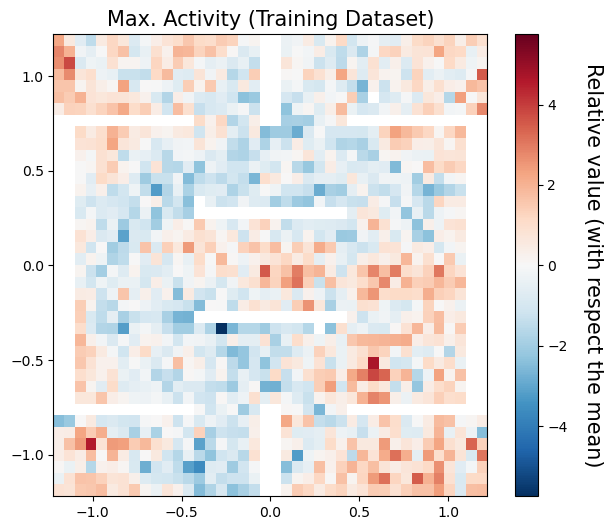

In [39]:
noReward_max_activity_heatmap = value_heatmap(noReward_DTmaze_position, noReward_relative_max_activity, title="Max. Activity (Training Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

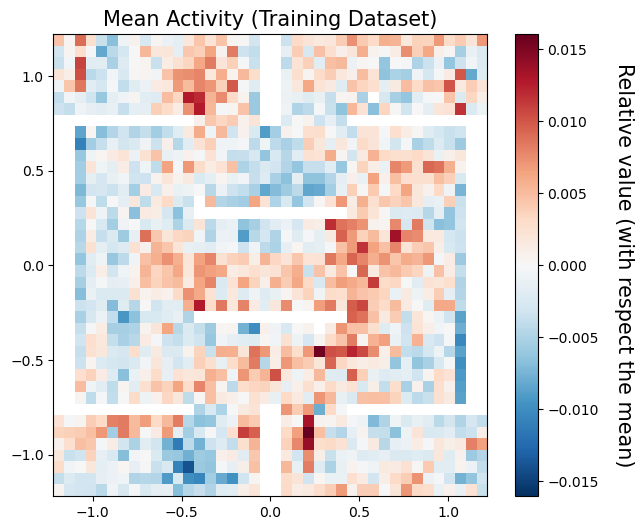

In [40]:
noReward_mean_activity_heatmap = value_heatmap(noReward_DTmaze_position, noReward_relative_mean_activity, title="Mean Activity (Training Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

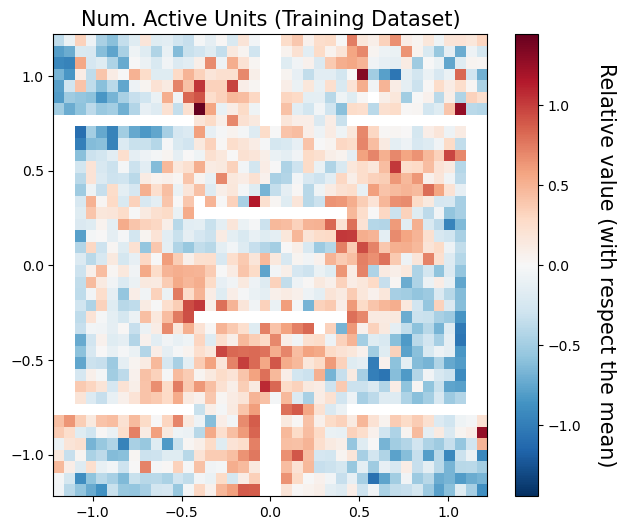

In [41]:
noReward_active_units_heatmap = value_heatmap(noReward_DTmaze_position, noReward_relative_num_active_units, title="Num. Active Units (Training Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

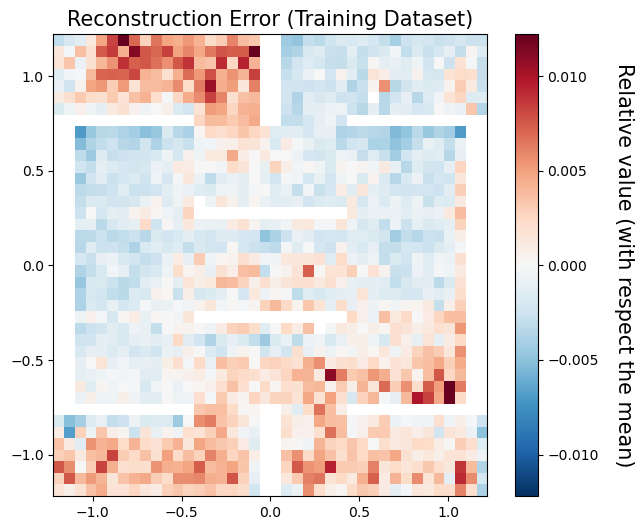

In [42]:
noReward_ReconError_heatmap = value_heatmap(noReward_DTmaze_position, noReward_relative_sample_loss, title="Reconstruction Error (Training Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

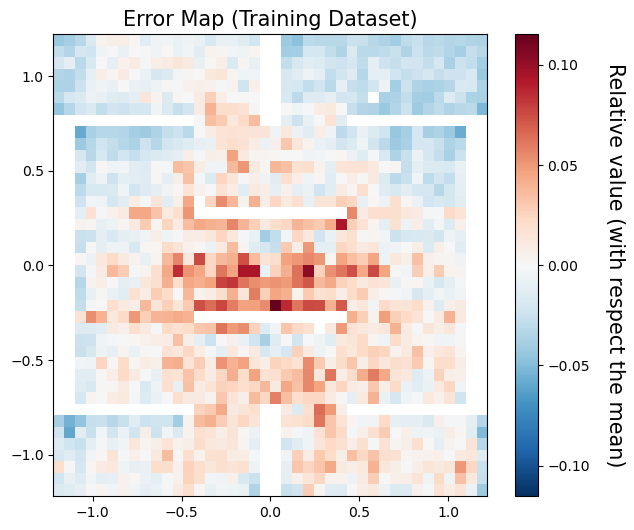

In [43]:
noReward_ErrorMap_heatmap = value_heatmap(noReward_DTmaze_position, noReward_relative_error_map, title="Error Map (Training Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

# Control No Reward 2 dataset

In [45]:
env = "DoubleTmazeNoReward2"
data_path, csv_filename, num_image = format_dataset(base_data_path, env)

print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Num. Images in Dataset = 40001
Dataset Path = D:\RORcogmaps_data/Datasets/DoubleTmazeNoReward2
CSV path =     D:\RORcogmaps_data/Datasets/DoubleTmazeNoReward2/data.csv


In [46]:
noReward2_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
noReward2_DTmaze_data, noReward2_DTmaze_position, noReward2_DTmaze_orientation = load_csv(csv_filename, num_images)

In [47]:
frames_to_remove = check_missing_frame(noReward2_DTmaze_data)
noReward2_dataset = clean_dataset(noReward2_dataset, frames_to_remove)

print("Dataset Shape =", noReward2_dataset.shape)
print("Position Shape =", noReward2_DTmaze_position.shape)
print()
noReward2_DTmaze_data

Frames ID to be removed from dataset = [35753]
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.999, 0.999, 0.499, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[3.14, 4.71]",False,0.014773,0.063646,300.698986,"[0.998, 0.998, 0.498, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[6.28, 6.28]",False,0.081278,0.171943,301.562288,"[0.997, 0.997, 0.497, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[1.57, 3.14]",False,0.112494,0.183708,332.673683,"[0.996, 0.996, 0.496, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[1.57, 3.14]",False,0.158347,0.188660,4.988723,"[0.995, 0.995, 0.495, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,40,1684.480,39996,[],"[1.57, 0.0]",False,-0.949096,-1.212840,1.498599,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0
39995,40,1685.504,39997,[],"[1.57, 0.0]",False,-0.931764,-1.213850,328.062598,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0
39996,40,1686.528,39998,[],"[5.5, 6.28]",False,-0.830556,-1.163206,342.414682,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0
39997,40,1687.552,39999,[],"[6.28, 4.71]",False,-0.734297,-1.111483,314.166358,"[0.0001, 0.0001, 0.0001, 0.0001]",0,"[0, 0, 0, 0]",0


Image shape = (120, 160, 3)


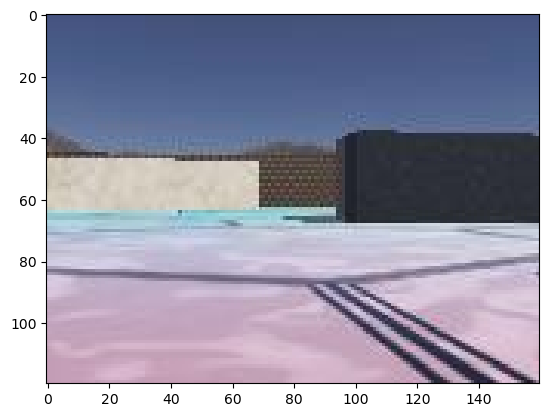

In [48]:
idx = 72
plt.imshow(noReward2_dataset[idx])
print("Image shape =", noReward2_dataset[idx].shape)

## Control Dataset exploration (No Reward 2)

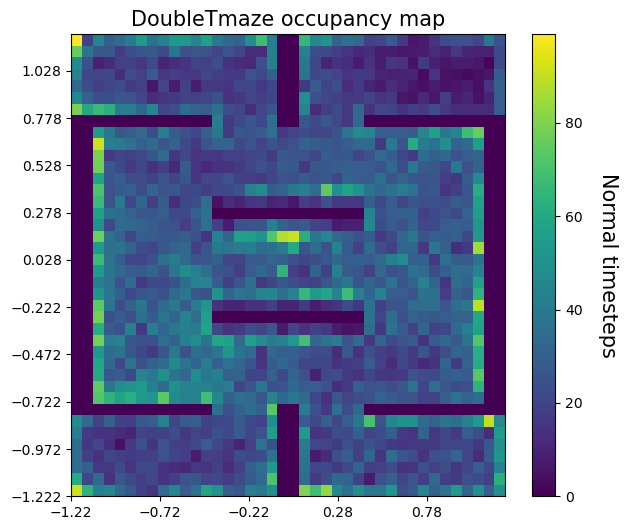

In [50]:
noReward2_hist = plot_occupancy_map(noReward2_DTmaze_position, plot_folder_path, save=False)

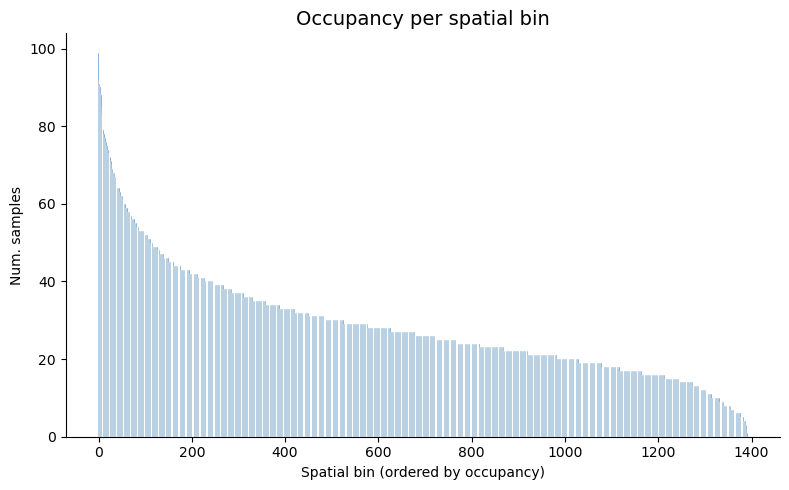

In [51]:
plot_samples_per_bin_hist(noReward2_hist)

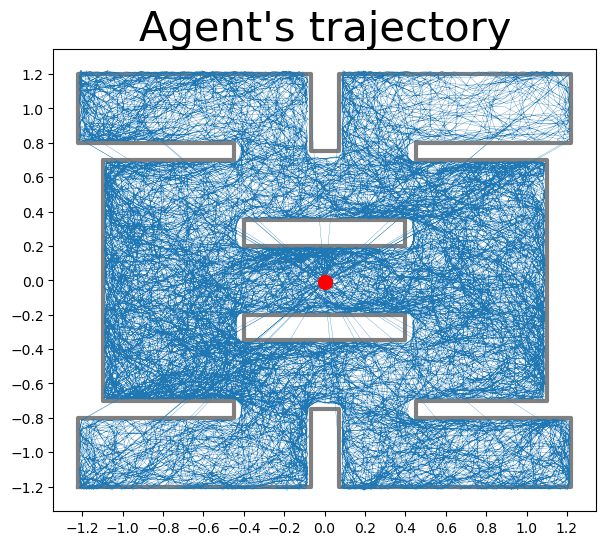

In [52]:
plot_agent_trajectory(noReward2_DTmaze_position, plot_folder_path, save=False)

## Evaluating Control embedding activity (No Reward 2)

In [54]:
noReward2_embeddings = get_latent_vectors(noReward2_dataset, model, batch_size=batch_size)

In [55]:
noReward2_max_activity = []
noReward2_mean_activity = []
activity_threshold = 0.001
noReward2_num_active_units = []

for i in range(len(noReward2_embeddings)):
    noReward2_max_activity.append(np.max(noReward2_embeddings[i]))
    noReward2_mean_activity.append(np.mean(noReward2_embeddings[i]))
    noReward2_num_active_units.append(np.sum(noReward2_embeddings[i] > activity_threshold))

Mean Embedding Max. Activity = 16.699694
Std. Embedding Max. Activity = 3.9702482


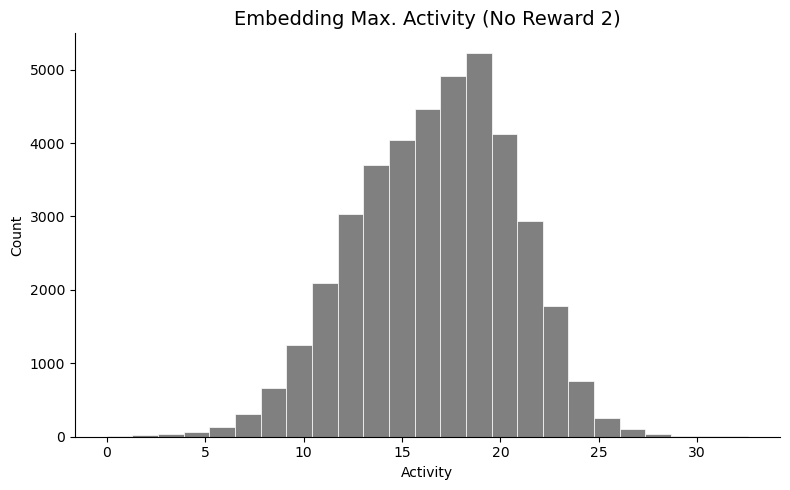

In [56]:
print('Mean Embedding Max. Activity =', np.mean(noReward2_max_activity))
print('Std. Embedding Max. Activity =', np.std(noReward2_max_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward2_max_activity, bins=25, color='gray', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Max. Activity (No Reward 2)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Mean Activity = 0.060877804
Std. Embedding Mean Activity = 0.013005888


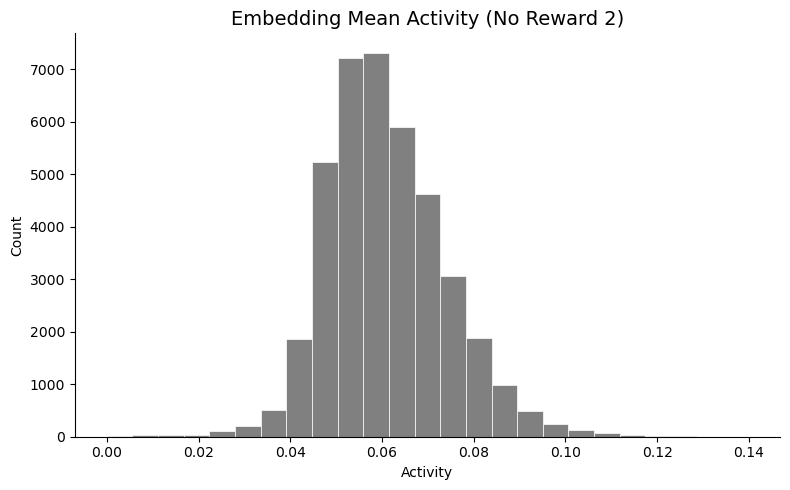

In [57]:
print('Mean Embedding Mean Activity =', np.mean(noReward2_mean_activity))
print('Std. Embedding Mean Activity =', np.std(noReward2_mean_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward2_mean_activity, bins=25, color='gray', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Mean Activity (No Reward 2)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Active Units = 2.713492837320933
Std. Embedding Active Units = 1.2054468156841607


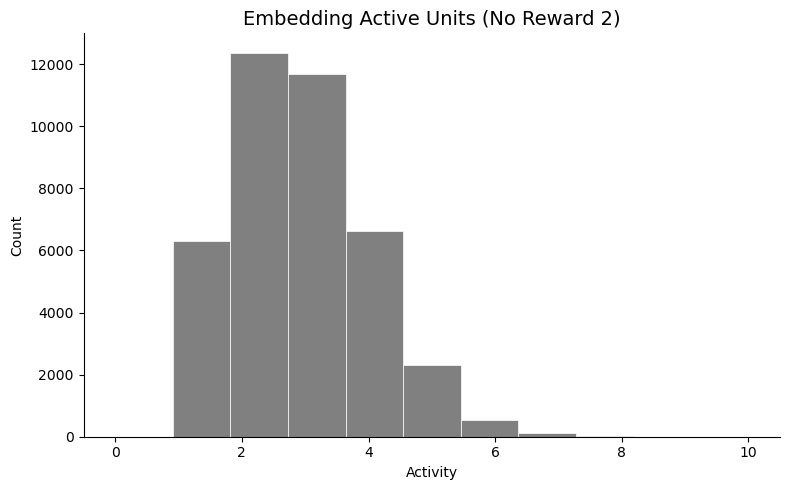

In [58]:
print('Mean Embedding Active Units =', np.mean(noReward2_num_active_units))
print('Std. Embedding Active Units =', np.std(noReward2_num_active_units))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(noReward2_num_active_units, bins=11, color='gray', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Active Units (No Reward 2)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Embedding dynamics in DoubleTmaze 2

In [60]:
noReward2_sample_loss = []
for i in range(len(noReward2_dataset)):
    noReward2_sample_loss.append(img_reconstruction_loss(model, noReward2_dataset[i]))

In [61]:
noReward2_sample_error_map = []
for i in range(len(noReward2_dataset)):
    error_map = img_pixelwise_reconstruction_loss(model, noReward2_dataset[i])
    noReward2_sample_error_map.append(np.percentile(error_map, 98))

In [62]:
noReward2_relative_max_activity = []
noReward2_relative_mean_activity = []
noReward2_relative_num_active_units = []
noReward2_relative_sample_loss = []
noReward2_relative_error_map = []

for i in range(len(noReward2_embeddings)):
    #noReward2_relative_max_activity.append(np.max(noReward2_embeddings[i]) - np.mean(noReward2_max_activity))
    #noReward2_relative_mean_activity.append(np.mean(noReward2_embeddings[i]) - np.mean(noReward2_mean_activity))
    #noReward2_relative_num_active_units.append(np.sum(noReward2_embeddings[i] > activity_threshold) - np.mean(noReward2_num_active_units))
    #noReward2_relative_sample_loss.append(noReward2_sample_loss[i] - np.mean(noReward2_sample_loss))
    #noReward2_relative_error_map.append(noReward2_sample_error_map[i] - np.mean(noReward2_sample_error_map))

    noReward2_relative_max_activity.append(np.max(noReward2_embeddings[i]) - baseline_max_activity)
    noReward2_relative_mean_activity.append(np.mean(noReward2_embeddings[i]) - baseline_mean_activity)
    noReward2_relative_num_active_units.append(np.sum(noReward2_embeddings[i] > activity_threshold) - baseline_num_active_units)
    noReward2_relative_sample_loss.append(noReward2_sample_loss[i] - baseline_sample_loss)
    noReward2_relative_error_map.append(noReward2_sample_error_map[i] - baseline_error_map)

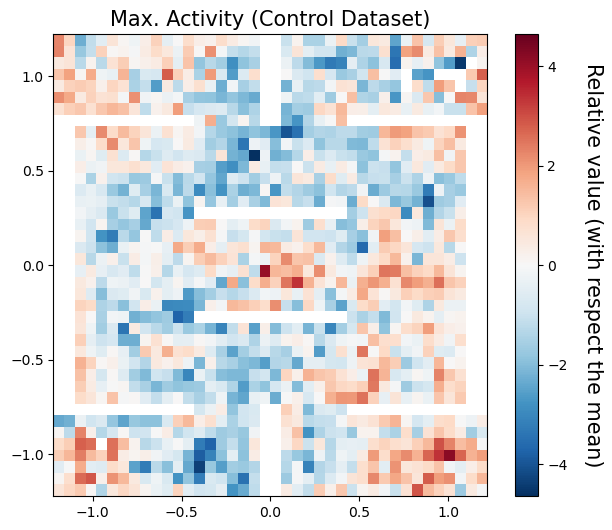

In [63]:
noReward2_max_activity_heatmap = value_heatmap(noReward2_DTmaze_position, noReward2_relative_max_activity, title="Max. Activity (Control Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

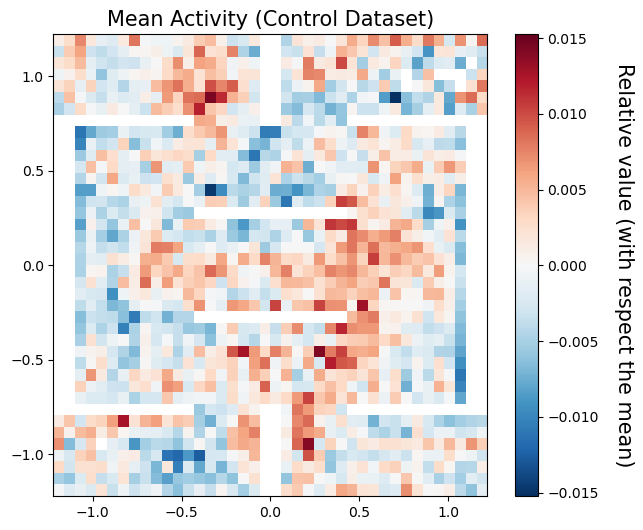

In [64]:
noReward2_mean_activity_heatmap = value_heatmap(noReward2_DTmaze_position, noReward2_relative_mean_activity, title="Mean Activity (Control Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

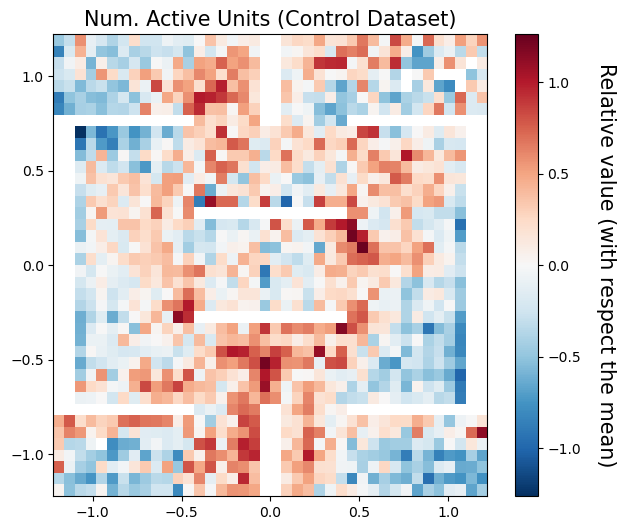

In [65]:
noReward2_active_units_heatmap = value_heatmap(noReward2_DTmaze_position, noReward2_relative_num_active_units, title="Num. Active Units (Control Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

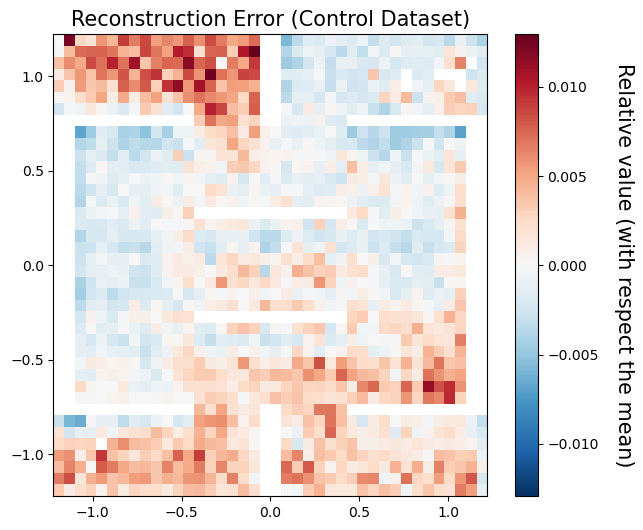

In [66]:
noReward2_ReconError_heatmap = value_heatmap(noReward2_DTmaze_position, noReward2_relative_sample_loss, title="Reconstruction Error (Control Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

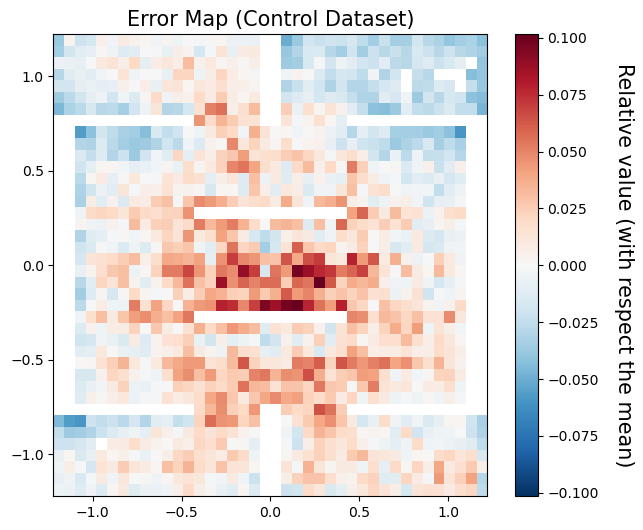

In [67]:
noReward2_ErrorMap_heatmap = value_heatmap(noReward2_DTmaze_position, noReward2_relative_error_map, title="Error Map (Control Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

# Introduction of Reward Dataset

In [69]:
env = "DoubleTmazeWithReward"
data_path, csv_filename, num_image = format_dataset(base_data_path, env)

print("Num. Images in Dataset =", num_images)
print("Dataset Path =", data_path)
print("CSV path =    ", csv_filename)

Num. Images in Dataset = 40001
Dataset Path = D:\RORcogmaps_data/Datasets/DoubleTmazeWithReward
CSV path =     D:\RORcogmaps_data/Datasets/DoubleTmazeWithReward/data.csv


In [70]:
withReward_dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
withReward_DTmaze_data, withReward_DTmaze_position, withReward_DTmaze_orientation = load_csv(csv_filename, num_image)

In [71]:
frames_to_remove = check_missing_frame(withReward_DTmaze_data)
withReward_dataset = clean_dataset(withReward_dataset, frames_to_remove)

print("Dataset Shape =", withReward_dataset.shape)
print("Position Shape =", withReward_DTmaze_position.shape)
print()
withReward_DTmaze_data

Frames ID to be removed from dataset = [38913]
Dataset Shape = (39999, 120, 160, 3)
Position Shape = (39999, 2)



,Trial_number,Trial_time,Frame_ID,Embedding,action,retrieved_action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,1.024,1,[],"[0, 0]",False,-0.000008,-0.009500,270.045416,"[0.999, 0.999, 0.499, 0.999]",0,"[0, 0, 0, 0]",0
1,0,2.048,2,[],"[3.14, 4.71]",False,0.014773,0.063646,300.698986,"[0.998, 0.998, 0.498, 0.998]",0,"[0, 0, 0, 0]",0
2,0,3.072,3,[],"[-0.79, 0.79]",False,0.012561,0.069629,333.209381,"[0.997, 0.997, 0.497, 0.997]",0,"[0, 0, 0, 0]",0
3,0,4.096,4,[],"[1.57, 3.14]",False,0.055525,0.082921,4.717325,"[0.996, 0.996, 0.496, 0.996]",0,"[0, 0, 0, 0]",0
4,0,5.120,5,[],"[1.57, 0.0]",False,0.073134,0.080475,334.251614,"[0.995, 0.995, 0.495, 0.995]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39994,27,811.008,39996,[],"[6.28, 6.28]",False,0.704303,0.916157,309.410819,"[0.0001, 0.208, 0.208, 0.208]",0,"[0, 0, 0, 0]",0
39995,27,812.032,39997,[],"[0.79, -0.79]",False,0.711441,0.917172,278.890626,"[0.0001, 0.207, 0.207, 0.207]",0,"[0, 0, 0, 0]",0
39996,27,813.056,39998,[],"[1.57, 0.0]",False,0.714613,0.933195,246.501770,"[0.0001, 0.206, 0.206, 0.206]",0,"[0, 0, 0, 0]",0
39997,27,814.080,39999,[],"[0.0, 1.57]",False,0.707339,0.947098,274.827475,"[0.0001, 0.205, 0.205, 0.205]",0,"[0, 0, 0, 0]",0


Image shape = (120, 160, 3)


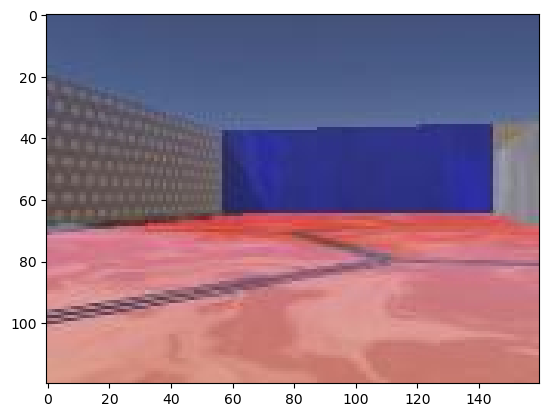

In [72]:
idx = 72
plt.imshow(withReward_dataset[idx])
print("Image shape =", withReward_dataset[idx].shape)

## Dataset exploration (With Reward)

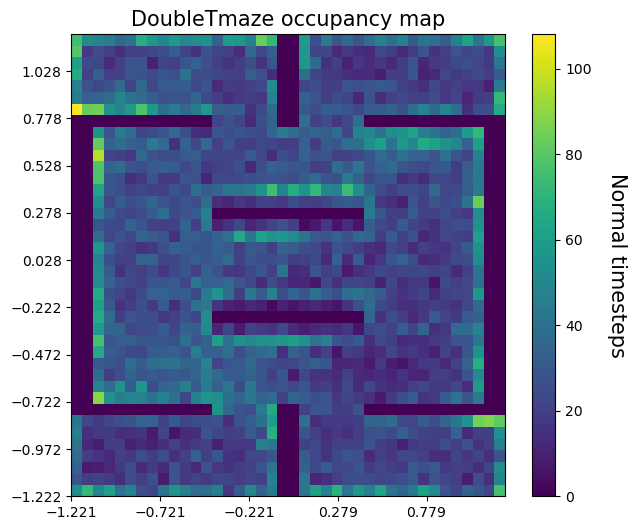

In [74]:
withReward_hist = plot_occupancy_map(withReward_DTmaze_position, plot_folder_path, save=False)

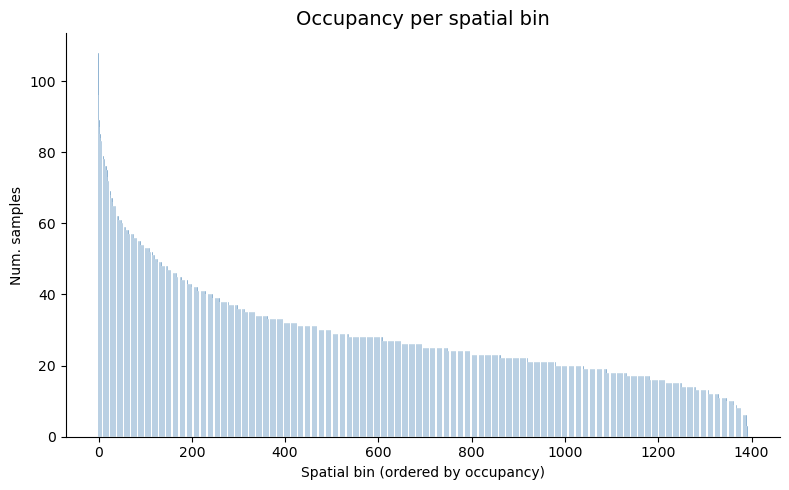

In [75]:
plot_samples_per_bin_hist(withReward_hist)

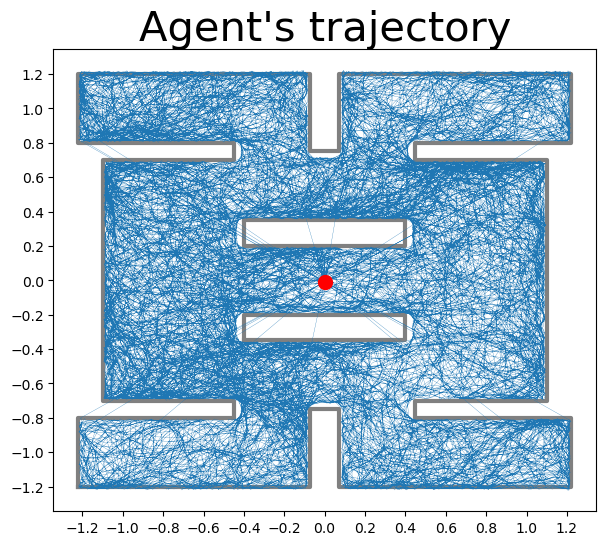

In [76]:
plot_agent_trajectory(withReward_DTmaze_position, plot_folder_path, save=False)

## Evaluating embedding activity (With Reward)

In [78]:
withReward_embeddings = get_latent_vectors(withReward_dataset, model, batch_size=batch_size)

In [79]:
withReward_max_activity = []
withReward_mean_activity = []
activity_threshold = 0.001
withReward_num_active_units = []

for i in range(len(withReward_embeddings)):
    withReward_max_activity.append(np.max(withReward_embeddings[i]))
    withReward_mean_activity.append(np.mean(withReward_embeddings[i]))
    withReward_num_active_units.append(np.sum(withReward_embeddings[i] > activity_threshold))

Mean Embedding Max. Activity = 16.620672
Std. Embedding Max. Activity = 4.0428433


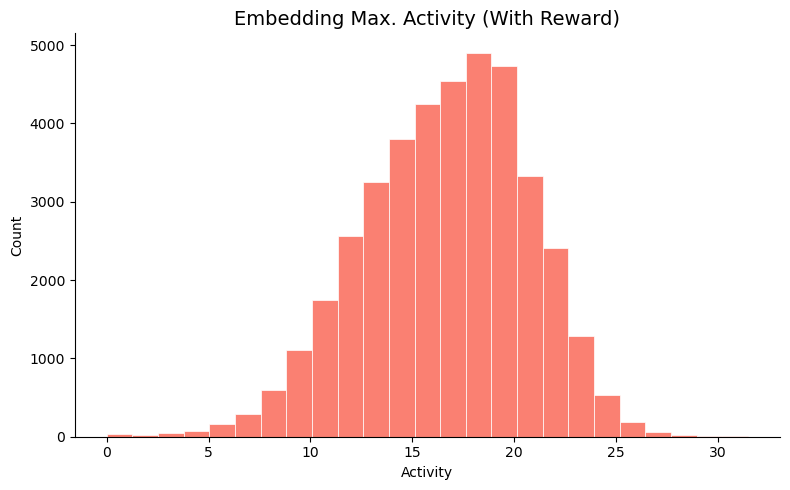

In [80]:
print('Mean Embedding Max. Activity =', np.mean(withReward_max_activity))
print('Std. Embedding Max. Activity =', np.std(withReward_max_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(withReward_max_activity, bins=25, color='salmon', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Max. Activity (With Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Mean Activity = 0.060554266
Std. Embedding Mean Activity = 0.013454675


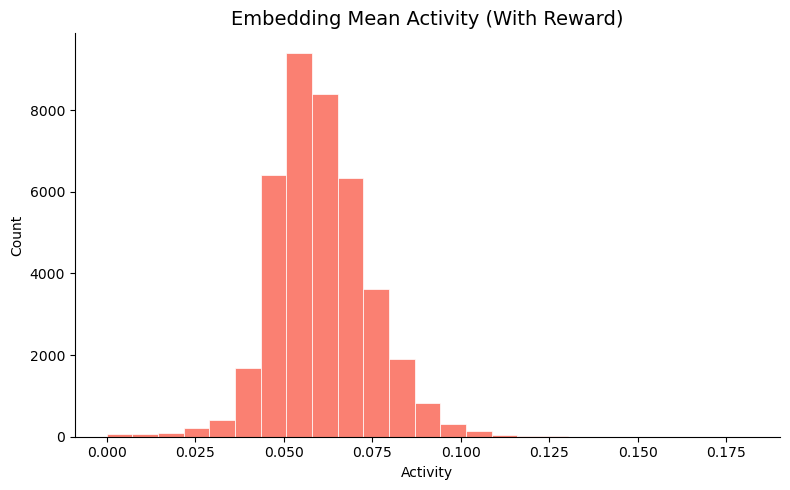

In [81]:
print('Mean Embedding Mean Activity =', np.mean(withReward_mean_activity))
print('Std. Embedding Mean Activity =', np.std(withReward_mean_activity))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(withReward_mean_activity, bins=25, color='salmon', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Mean Activity (With Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Mean Embedding Active Units = 2.708842721068027
Std. Embedding Active Units = 1.2051206852990324


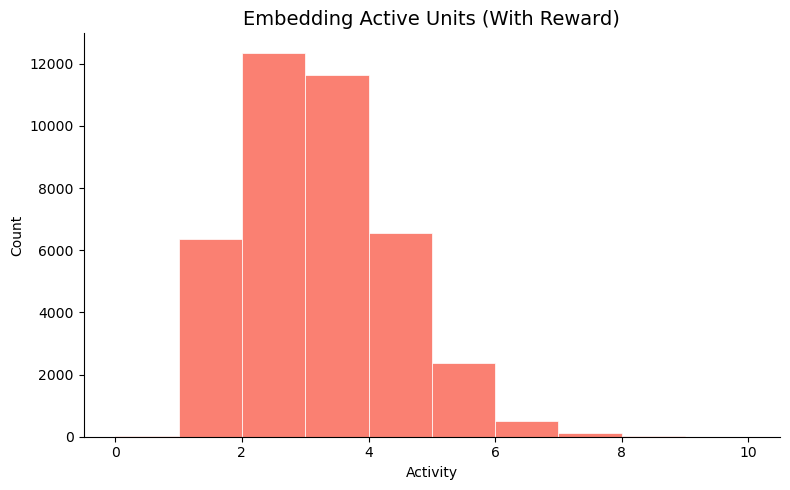

In [82]:
print('Mean Embedding Active Units =', np.mean(withReward_num_active_units))
print('Std. Embedding Active Units =', np.std(withReward_num_active_units))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(withReward_num_active_units, bins=10, color='salmon', edgecolor='white', linewidth=0.5)
ax.set_title('Embedding Active Units (With Reward)', fontsize=14)
ax.set_xlabel('Activity')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Embedding max activity = 15.300003
Embedding mean activity = 0.038250007
Num. active units = 1


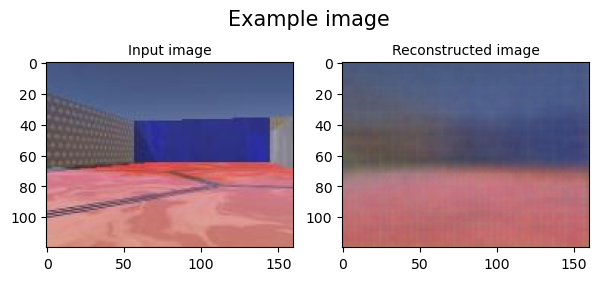

In [83]:
img_indx = 72
print('Embedding max activity =' , np.max(withReward_embeddings[img_indx]))
print('Embedding mean activity =' , np.mean(withReward_embeddings[img_indx]))
print('Num. active units =' , np.sum(withReward_embeddings[img_indx] > activity_threshold))

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(withReward_dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(withReward_dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

In [84]:
witReward_sample_loss = []
for i in range(len(withReward_dataset)):
    witReward_sample_loss.append(img_reconstruction_loss(model, withReward_dataset[i]))

In [85]:
witReward_sample_error_map = []
for i in range(len(withReward_dataset)):
    error_map = img_pixelwise_reconstruction_loss(model, withReward_dataset[i])
    witReward_sample_error_map.append(np.percentile(error_map, 98))

In [86]:
withReward_relative_max_activity = []
withReward_relative_mean_activity = []
withReward_relative_num_active_units = []
withReward_relative_sample_loss = []
withReward_relative_error_map = []

for i in range(len(withReward_embeddings)):
    #withReward_relative_max_activity.append(np.max(withReward_embeddings[i]) - np.mean(withReward_max_activity))
    #withReward_relative_mean_activity.append(np.mean(withReward_embeddings[i]) - np.mean(withReward_mean_activity))
    #withReward_relative_num_active_units.append(np.sum(withReward_embeddings[i] > activity_threshold) - np.mean(withReward_num_active_units))
    #withReward_relative_sample_loss.append(witReward_sample_loss[i] - np.mean(witReward_sample_loss))
    #withReward_relative_error_map.append(witReward_sample_error_map[i] - np.mean(witReward_sample_error_map))

    withReward_relative_max_activity.append(np.max(withReward_embeddings[i]) - baseline_max_activity)
    withReward_relative_mean_activity.append(np.mean(withReward_embeddings[i]) - baseline_mean_activity)
    withReward_relative_num_active_units.append(np.sum(withReward_embeddings[i] > activity_threshold) - baseline_num_active_units)
    withReward_relative_sample_loss.append(witReward_sample_loss[i] - baseline_sample_loss)
    withReward_relative_error_map.append(witReward_sample_error_map[i] - baseline_error_map)

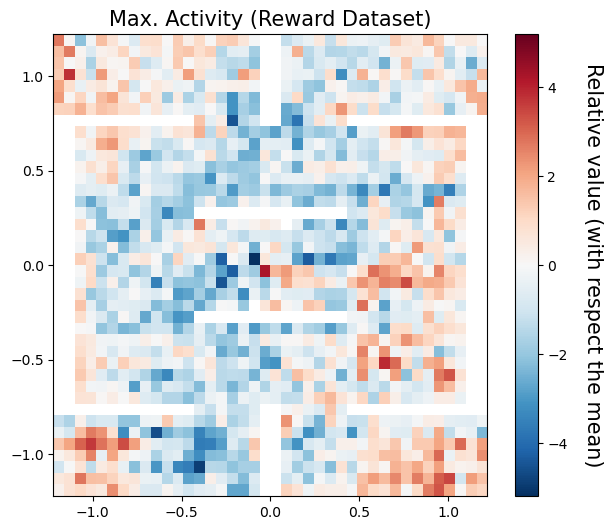

In [87]:
withReward_max_activity_heatmap = value_heatmap(withReward_DTmaze_position, withReward_relative_max_activity, title="Max. Activity (Reward Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

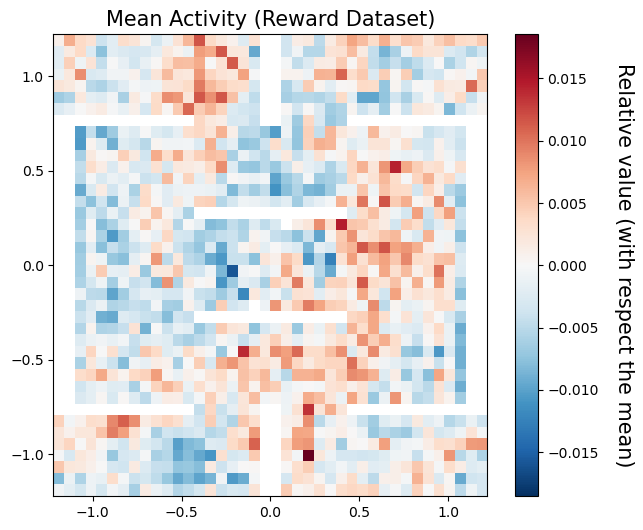

In [88]:
withReward_mean_activity_heatmap = value_heatmap(withReward_DTmaze_position, withReward_relative_mean_activity, title="Mean Activity (Reward Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

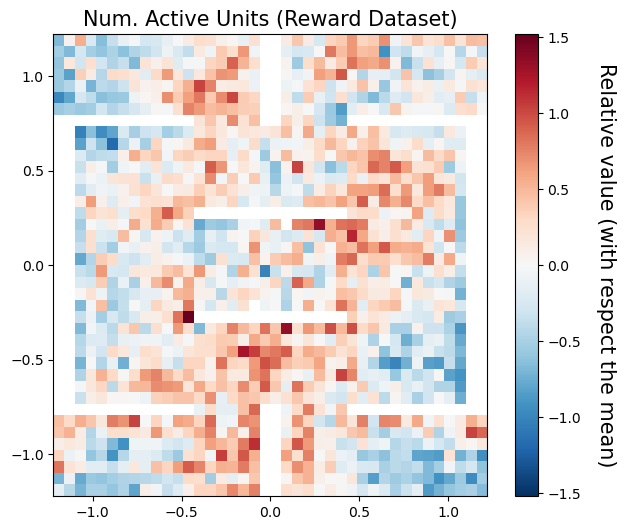

In [89]:
withReward_active_units_heatmap = value_heatmap(withReward_DTmaze_position, withReward_relative_num_active_units, title="Num. Active Units (Reward Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

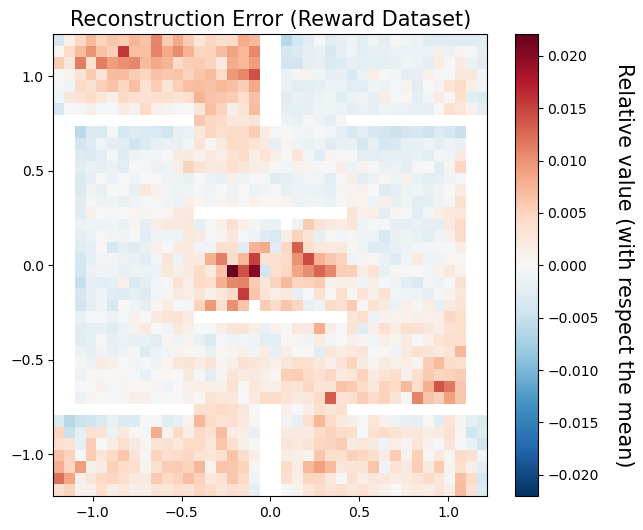

In [90]:
withReward_ReconError_heatmap = value_heatmap(withReward_DTmaze_position, withReward_relative_sample_loss, title="Reconstruction Error (Reward Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

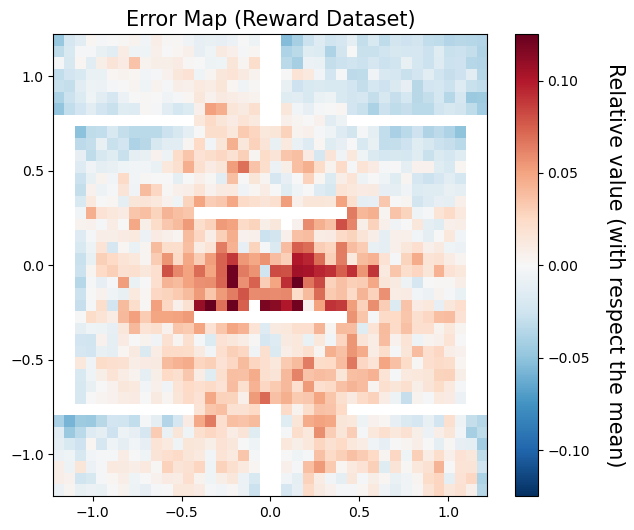

In [91]:
withReward_ErrorMap_heatmap = value_heatmap(withReward_DTmaze_position, withReward_relative_error_map, title="Error Map (Reward Dataset)", plot_path=plot_folder_path, save=save_supp_plots)

## Searching for novelty signatures in model's embedding

We are going to explore:
- Embedding max activity.
- Embedding mean activity.
- Num. of active units in the embedding.
- Model MSE Reconstruction Loss. How good the model reconstruct new inputs.
- Model Reconstruction Error Map. Maximal (percentil 98) partial loss within the sample.

## Comparing reaction to novelty

To generate the following heatmaps, we have followed the steps:
1. We have created 3 heatmaps (2 No Reward and 1 With Reward). Each of these heatmaps shows the value of a given variable (e.g., maximal unit activity) divided by the maximum value

In [95]:
noReward_max_activity_values = noReward2_max_activity_heatmap - noReward_max_activity_heatmap
withReward_max_activity_values = withReward_max_activity_heatmap - noReward_max_activity_heatmap
noReward_mean_activity_values = noReward2_mean_activity_heatmap - noReward_mean_activity_heatmap
withReward_mean_activity_values = withReward_mean_activity_heatmap - noReward_mean_activity_heatmap
noReward_active_units_values = noReward2_active_units_heatmap - noReward_active_units_heatmap
withReward_active_units_values = withReward_active_units_heatmap - noReward_active_units_heatmap
noReward_ReconError_values = noReward2_ReconError_heatmap - noReward_ReconError_heatmap
withReward_ReconError_values = withReward_ReconError_heatmap - noReward_ReconError_heatmap
noReward_ErrorMap_values = noReward2_ErrorMap_heatmap - noReward_ErrorMap_heatmap
withReward_ErrorMap_values = withReward_ErrorMap_heatmap - noReward_ErrorMap_heatmap

Max. absolute value = 1.554670493134061


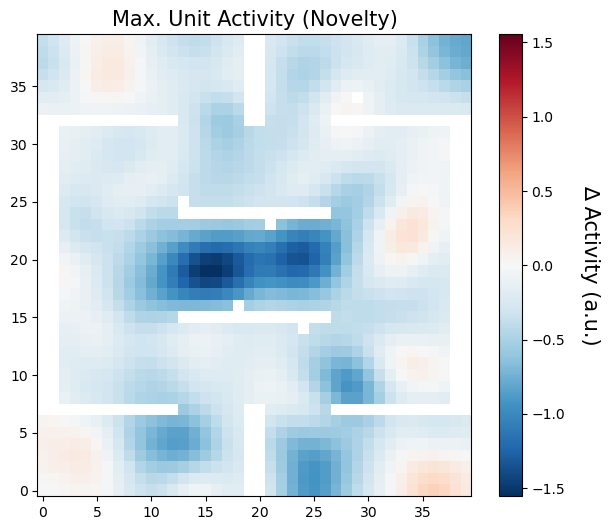

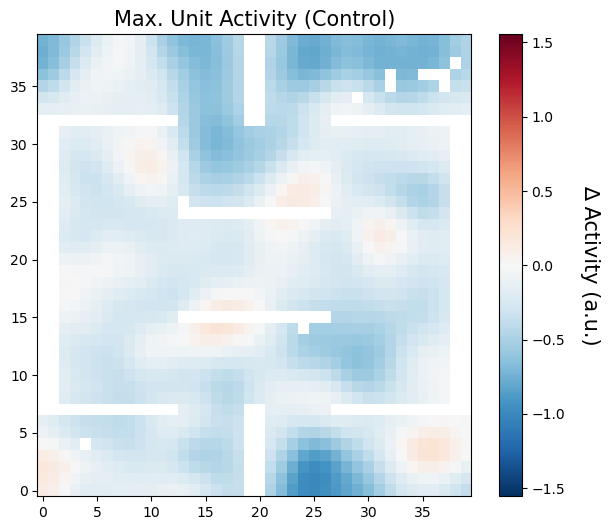

1.0028975913740215

In [96]:
cbar_lim = change_heatmap(withReward_max_activity_values, title="Max. Unit Activity (Novelty)", cbar_label="∆ Activity (a.u.)", save=save_plots, plot_path=plot_folder_path)
change_heatmap(noReward_max_activity_values, title="Max. Unit Activity (Control)", cbar_lim=cbar_lim, cbar_label="∆ Activity (a.u.)", save=save_plots, plot_path=plot_folder_path)

Max. absolute value = 0.006917919139391654


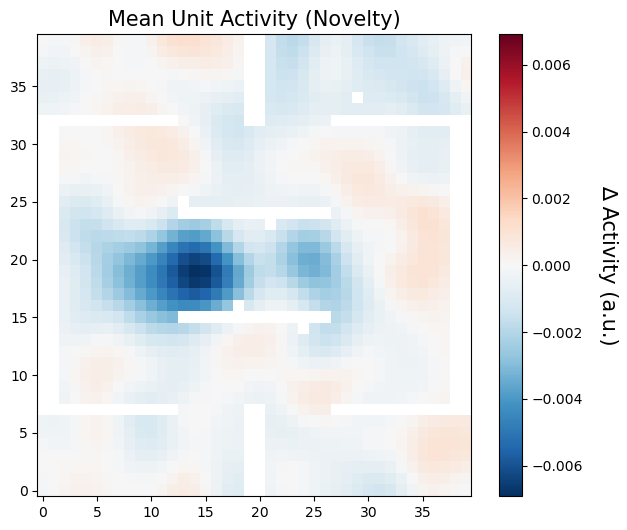

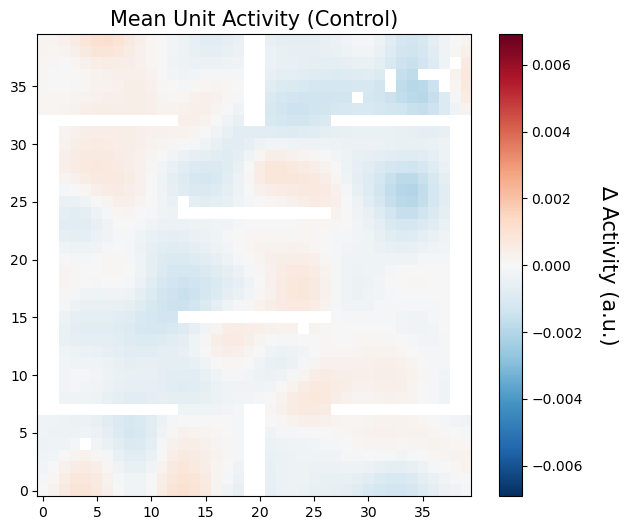

0.0020043090932207507

In [97]:
cbar_lim = change_heatmap(withReward_mean_activity_values, title="Mean Unit Activity (Novelty)", cbar_label="∆ Activity (a.u.)", save=save_plots, plot_path=plot_folder_path)
change_heatmap(noReward_mean_activity_values, title="Mean Unit Activity (Control)", cbar_lim=cbar_lim, cbar_label="∆ Activity (a.u.)", save=save_plots, plot_path=plot_folder_path)

Max. absolute value = 0.22865502536782129


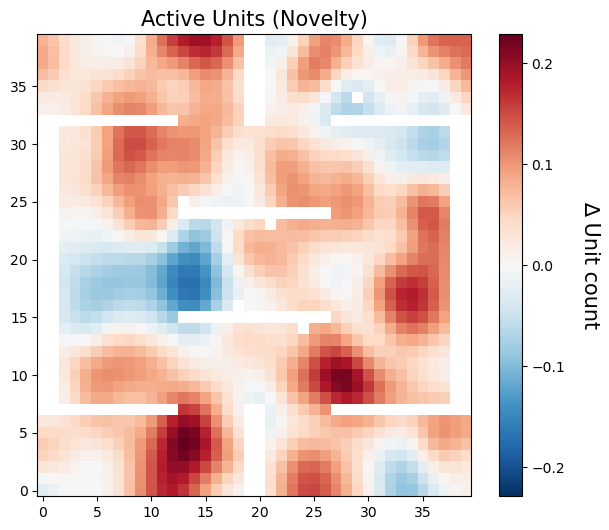

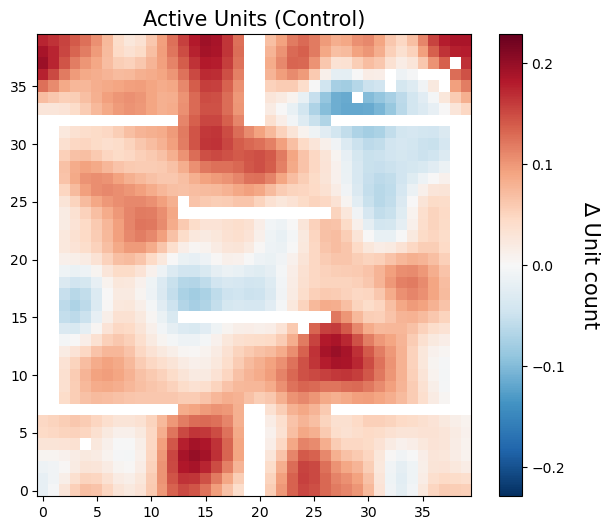

0.19972566524851165

In [98]:
cbar_lim = change_heatmap(withReward_active_units_values, title="Active Units (Novelty)", cbar_label="∆ Unit count", save=save_plots, plot_path=plot_folder_path)
change_heatmap(noReward_active_units_values, title="Active Units (Control)", cbar_lim=cbar_lim, cbar_label="∆ Unit count", save=save_plots, plot_path=plot_folder_path)

Max. absolute value = 0.005897106569390054


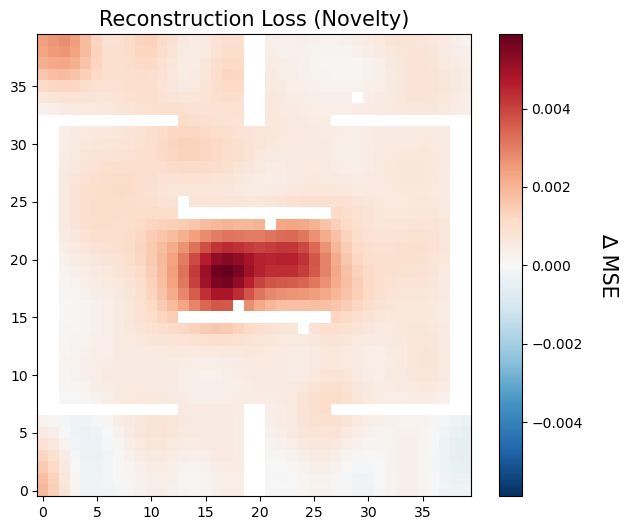

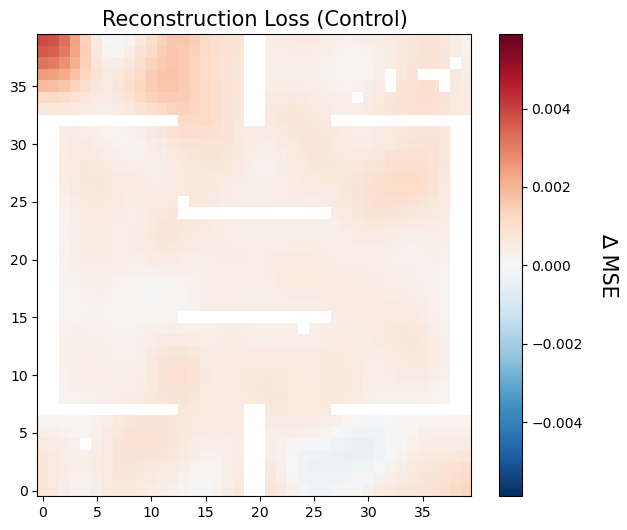

0.0038952532502149542

In [99]:
cbar_lim = change_heatmap(withReward_ReconError_values, title="Reconstruction Loss (Novelty)", cbar_label="∆ MSE", save=save_plots, plot_path=plot_folder_path)
change_heatmap(noReward_ReconError_values, title="Reconstruction Loss (Control)", cbar_lim=cbar_lim, cbar_label="∆ MSE", save=save_plots, plot_path=plot_folder_path)

Max. absolute value = 0.023098414977469617


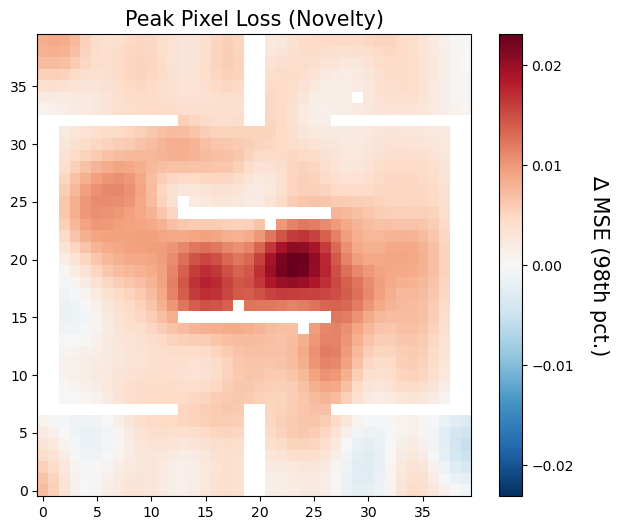

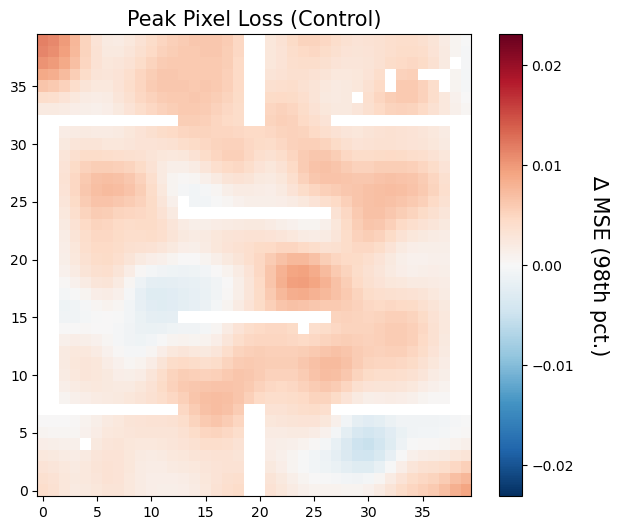

0.011592916552788178

In [100]:
cbar_lim = change_heatmap(withReward_ErrorMap_values, title="Peak Pixel Loss (Novelty)", cbar_label="∆ MSE (98th pct.)", save=save_plots, plot_path=plot_folder_path)
change_heatmap(noReward_ErrorMap_values, title="Peak Pixel Loss (Control)", cbar_lim=cbar_lim, cbar_label="∆ MSE (98th pct.)", save=save_plots, plot_path=plot_folder_path)